# Model Building & Evaluation (Task 2)

Baseline Logistic Regression vs an ensemble (XGBoost / Random Forest) on both datasets, evaluated with **AUC-PR, F1, confusion matrix** and 5-fold CV.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd()
ROOT = ROOT.parent if ROOT.name == 'notebooks' else ROOT
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 60)


In [2]:
from src import config, preprocessing, modeling, evaluation
fraud = pd.read_csv(config.PROCESSED_DIR/'fraud_data_processed.csv')
X, y = preprocessing.select_fraud_model_columns(fraud)
X_tr, X_te, y_tr, y_te = preprocessing.stratified_split(X, y)
print('train', X_tr.shape, 'test', X_te.shape, '| test frauds:', int(y_te.sum()))

train (120889, 14) test (30223, 14) | test frauds: 2830


## Baseline - Logistic Regression (`class_weight='balanced'`)

In [3]:
lr = preprocessing.make_plain_pipeline(preprocessing.build_fraud_preprocessor(X_tr), modeling.make_logistic_regression())
lr.fit(X_tr, y_tr)
lr_score = lr.predict_proba(X_te)[:,1]; lr_pred = (lr_score>=0.5).astype(int)
rec_lr = evaluation.evaluate(y_te, lr_pred, lr_score, 'LogisticRegression'); rec_lr

{'model': 'LogisticRegression',
 'auc_pr': 0.6676320586577581,
 'roc_auc': 0.8406173251813449,
 'f1': 0.6233944168522008,
 'precision': 0.6048521103356597,
 'recall': 0.6431095406360424}

## Ensemble - XGBoost (`scale_pos_weight` for imbalance)

In [4]:
spw = modeling.imbalance_ratio(y_tr)
try:
    est = modeling.make_xgboost(scale_pos_weight=spw); name='xgboost'
except ImportError:
    est = modeling.make_random_forest(); name='random_forest'
ens = preprocessing.make_plain_pipeline(preprocessing.build_fraud_preprocessor(X_tr), est)
ens.fit(X_tr, y_tr)
ens_score = ens.predict_proba(X_te)[:,1]; ens_pred = (ens_score>=0.5).astype(int)
rec_ens = evaluation.evaluate(y_te, ens_pred, ens_score, name); rec_ens

{'model': 'xgboost',
 'auc_pr': 0.7161117950374837,
 'roc_auc': 0.8447822423489325,
 'f1': 0.6150477084310965,
 'precision': 0.5517822060061746,
 'recall': 0.6946996466431096}

## Comparison table

In [5]:
display(evaluation.metrics_table([rec_lr, rec_ens]))

,auc_pr,roc_auc,f1,precision,recall
model,,,,,
xgboost,0.7161,0.8448,0.6150,0.5518,0.6947
LogisticRegression,0.6676,0.8406,0.6234,0.6049,0.6431


## Confusion matrices & PR curves

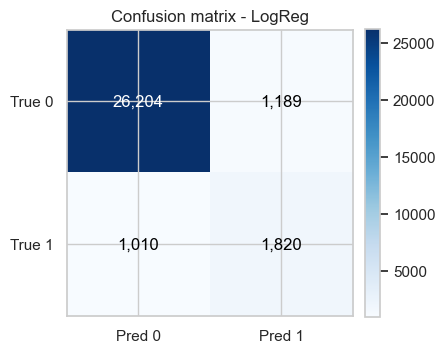

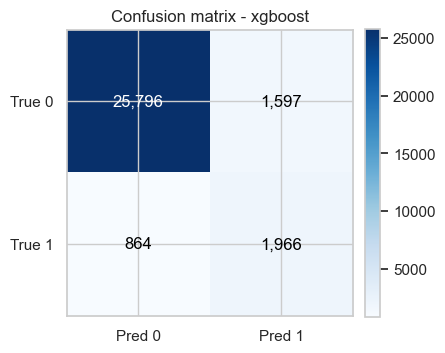

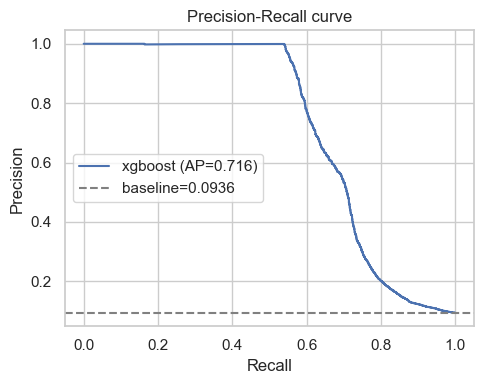

In [6]:
evaluation.plot_confusion_matrix(y_te, lr_pred, 'LogReg', config.FIGURES_DIR/'cm_fraud_lr.png')
evaluation.plot_confusion_matrix(y_te, ens_pred, name, config.FIGURES_DIR/'cm_fraud_ens.png')
evaluation.plot_pr_curve(y_te, ens_score, name, config.FIGURES_DIR/'pr_fraud_ens.png')
plt.show()

## 5-fold Stratified Cross-Validation

In [7]:
cv = modeling.cross_validate_model(ens, X, y, k=5)
for m,(mu,sd) in cv.items(): print(f'{m:10s}: {mu:.4f} +/- {sd:.4f}')

auc_pr    : 0.7159 +/- 0.0114
roc_auc   : 0.8428 +/- 0.0084
f1        : 0.6197 +/- 0.0073
recall    : 0.6961 +/- 0.0105
precision : 0.5585 +/- 0.0056


## Save the best model

In [8]:
best = ens  # ensemble selected on AUC-PR; see comparison table
modeling.save_model(best, 'fraud_data_best')
print('saved -> models/fraud_data_best.joblib')

saved -> models/fraud_data_best.joblib


---
## Credit-card dataset
Same procedure on the PCA-anonymised bank data.

In [9]:
cc = pd.read_csv(config.PROCESSED_DIR/'creditcard_processed.csv')
Xc = cc.drop(columns=[config.CREDITCARD_TARGET]); yc = cc[config.CREDITCARD_TARGET]
Xc_tr, Xc_te, yc_tr, yc_te = preprocessing.stratified_split(Xc, yc)
lrc = preprocessing.make_plain_pipeline(preprocessing.build_creditcard_preprocessor(Xc_tr), modeling.make_logistic_regression())
lrc.fit(Xc_tr, yc_tr)
sc = lrc.predict_proba(Xc_te)[:,1]; pc = (sc>=0.5).astype(int)
rec_lrc = evaluation.evaluate(yc_te, pc, sc, 'LogReg-CC')
try:
    estc = modeling.make_xgboost(scale_pos_weight=modeling.imbalance_ratio(yc_tr)); ncc='xgboost-CC'
except ImportError:
    estc = modeling.make_random_forest(); ncc='rf-CC'
ensc = preprocessing.make_plain_pipeline(preprocessing.build_creditcard_preprocessor(Xc_tr), estc)
ensc.fit(Xc_tr, yc_tr)
scs = ensc.predict_proba(Xc_te)[:,1]; pcs=(scs>=0.5).astype(int)
rec_ensc = evaluation.evaluate(yc_te, pcs, scs, ncc)
display(evaluation.metrics_table([rec_lrc, rec_ensc]))
modeling.save_model(ensc, 'creditcard_best')

,auc_pr,roc_auc,f1,precision,recall
model,,,,,
xgboost-CC,0.8204,0.9776,0.8471,0.9600,0.7579
LogReg-CC,0.6719,0.9657,0.1059,0.0564,0.8737


WindowsPath('C:/Users/hp/Documents/fraud-detection/models/creditcard_best.joblib')

### Model selection
Select on **AUC-PR** (the right summary metric for imbalanced data), using F1 and the confusion matrix to weigh the false-positive vs false-negative trade-off. The ensemble typically wins on AUC-PR while Logistic Regression remains the interpretable reference. The chosen model is carried into the SHAP notebook.